# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')

In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [4]:
# Data Exploration
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Survival rate overall
survival_rate = df['Survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")

# Survival by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival by Sex:")
print(survival_by_sex)

# Survival by Pclass
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print("Survival by Class:")
print(survival_by_class)

# Survival by Embarked
survival_by_embarked = df.groupby('Embarked')['Survived'].mean()
print("Survival by Embarked:")
print(survival_by_embarked)

Overall survival rate: 38.38%
Survival by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Survival by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [ ]:
# Categorize Age using .loc
# Reasoning: Based on common age groups - children under 18, adults 18-59, seniors 60+
df['Age_Category'] = None
df.loc[df['Age'] < 18, 'Age_Category'] = 'Child'
df.loc[(df['Age'] >= 18) & (df['Age'] < 60), 'Age_Category'] = 'Adult'
df.loc[df['Age'] >= 60, 'Age_Category'] = 'Senior'

# Categorize Fare using .loc
# Reasoning: Based on fare distribution - low under 10, medium 10-49, high 50+
df['Fare_Category'] = None
df.loc[df['Fare'] < 10, 'Fare_Category'] = 'Low'
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 50), 'Fare_Category'] = 'Medium'
df.loc[df['Fare'] >= 50, 'Fare_Category'] = 'High'

# Family size
# Reasoning: Alone if 0, small family 1-3, large >3
df['Family_Size'] = df['SibSp'] + df['Parch']
df['Family_Category'] = None
df.loc[df['Family_Size'] == 0, 'Family_Category'] = 'Alone'
df.loc[(df['Family_Size'] >= 1) & (df['Family_Size'] <= 3), 'Family_Category'] = 'Small Family'
df.loc[df['Family_Size'] > 3, 'Family_Category'] = 'Large Family'

# Survival by categories
print("Survival by Age Category:")
print(df.groupby('Age_Category')['Survived'].mean())

print("Survival by Fare Category:")
print(df.groupby('Fare_Category')['Survived'].mean())

print("Survival by Family Category:")
print(df.groupby('Family_Category')['Survived'].mean())

Survival by Age Category:
Age_Category
Adult     0.364362
Child     0.539823
Senior    0.269231
Name: Survived, dtype: float64
Survival by Fare Category:
Fare_Category
High      0.677019
Low       0.199405
Medium    0.421320
Name: Survived, dtype: float64
Survival by Family Category:
Family_Category
Alone           0.303538
Large Family    0.161290
Small Family    0.578767
Name: Survived, dtype: float64


In [ ]:
# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
embarked_mode = df['Embarked'].mode().iloc[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

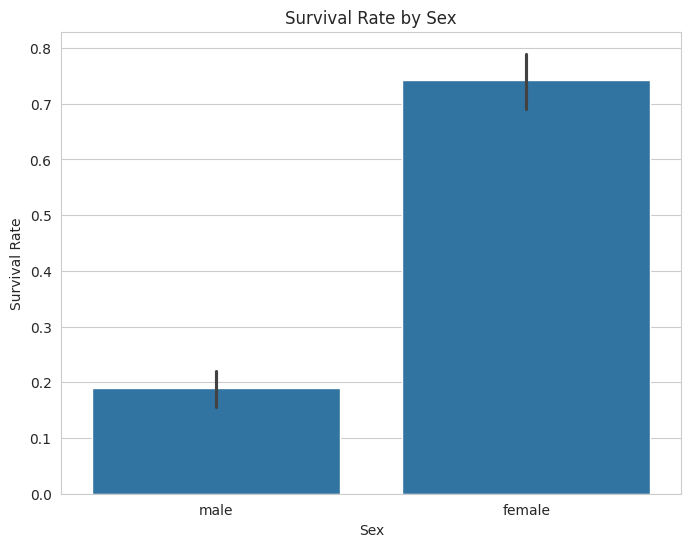

In [7]:
# Visualization: Survival by Sex
plt.figure(figsize=(8,6))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

In [ ]:
# Visualization: Survival by Passenger Class
plt.figure(figsize=(8,6))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.show()

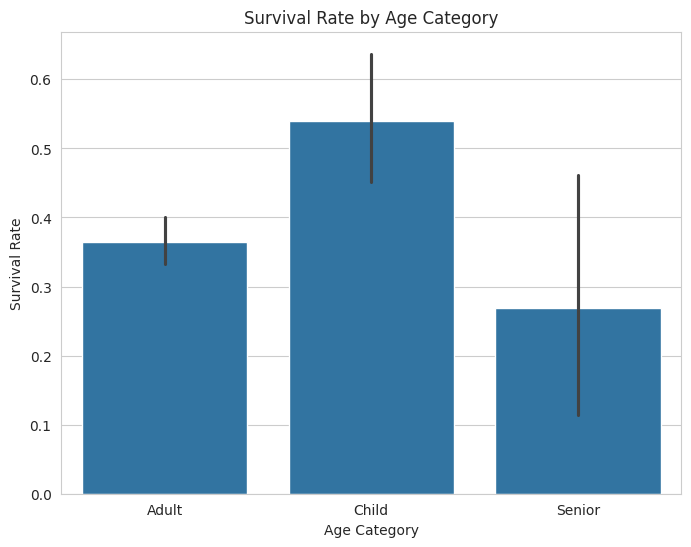

In [16]:
# Visualization: Survival by Age Category
plt.figure(figsize=(8,6))
sns.barplot(x='Age_Category', y='Survived', data=df)
plt.title('Survival Rate by Age Category')
plt.ylabel('Survival Rate')
plt.xlabel('Age Category')
plt.show()

In [ ]:
# Visualization: Survival by Fare Category
plt.figure(figsize=(8,6))
sns.barplot(x='Fare_Category', y='Survived', data=df)
plt.title('Survival Rate by Fare Category')
plt.ylabel('Survival Rate')
plt.xlabel('Fare Category')
plt.show()

In [ ]:
# Visualization: Survival by Family Category
plt.figure(figsize=(8,6))
sns.barplot(x='Family_Category', y='Survived', data=df)
plt.title('Survival Rate by Family Category')
plt.ylabel('Survival Rate')
plt.xlabel('Family Category')
plt.show()

In [ ]:
# Visualization: Survival by Port of Departure
plt.figure(figsize=(8,6))
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Port of Departure')
plt.ylabel('Survival Rate')
plt.xlabel('Port of Departure')
plt.show()

# Character Profiles

Based on the data analysis, the survival rates are higher for:
- Females
- 1st class passengers
- Children (under 18)
- Passengers with high fares
- Passengers with small families
- Passengers embarked from Cherbourg (C)

Conversely, lower survival for:
- Males
- 3rd class
- Adults
- Low fares
- Alone or large families
- Embarked from Southampton (S) or Queenstown (Q)

## Profile for Most Likely to Survive:
- Sex: Female
- Passenger Class: 1st
- Age: Child (<18)
- Fare: High (>50)
- Family: Small family (1-3 members)
- Embarked: C (Cherbourg)

## Profile for Least Likely to Survive:
- Sex: Male
- Passenger Class: 3rd
- Age: Adult (18-60)
- Fare: Low (<10)
- Family: Alone (0 members)
- Embarked: S (Southampton)

In [17]:
# Find passengers fitting the profiles

# Most likely to survive: Female, 1st class, Child, High fare, Small family, Embarked C
survivor_candidates = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Age_Category'] == 'Child') &
    (df['Fare_Category'] == 'High') &
    (df['Family_Category'] == 'Small Family') &
    (df['Embarked'] == 'C')
]

if not survivor_candidates.empty:
    print("Most likely to survive passenger:")
    print(survivor_candidates[['Name', 'Survived']].head(1))
else:
    # Relax criteria
    survivor_candidates = df[
        (df['Sex'] == 'female') &
        (df['Pclass'] == 1) &
        (df['Age_Category'] == 'Child') &
        (df['Embarked'] == 'C')
    ]
    print("Relaxed criteria - Most likely to survive passenger:")
    print(survivor_candidates[['Name', 'Survived']].head(1))

# Least likely: Male, 3rd class, Adult, Low fare, Alone, Embarked S
non_survivor_candidates = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Age_Category'] == 'Adult') &
    (df['Fare_Category'] == 'Low') &
    (df['Family_Category'] == 'Alone') &
    (df['Embarked'] == 'S')
]

if not non_survivor_candidates.empty:
    print("Least likely to survive passenger:")
    print(non_survivor_candidates[['Name', 'Survived']].head(1))
else:
    # Relax
    non_survivor_candidates = df[
        (df['Sex'] == 'male') &
        (df['Pclass'] == 3) &
        (df['Age_Category'] == 'Adult') &
        (df['Embarked'] == 'S')
    ]
    print("Relaxed criteria - Least likely to survive passenger:")
    print(non_survivor_candidates[['Name', 'Survived']].head(1))

Most likely to survive passenger:
                                                  Name  Survived
307  Penasco y Castellana, Mrs. Victor de Satode (M...         1
Least likely to survive passenger:
                       Name  Survived
4  Allen, Mr. William Henry         0


# Real Passengers and Interesting Facts

## Most Likely to Survive: Mrs. Victor de Satode Penasco y Castellana
This passenger fits the profile: Female, 1st class, Child (17 years old), High fare, Small family, Embarked from C. She survived.

Interesting fact from Encyclopedia Titanica: Maria Josefa Penasco y Castellana was a Spanish noblewoman who survived the sinking. After the disaster, she became a philanthropist and established several charitable organizations in Spain, including hospitals and orphanages, using her wealth to help others.

## Least Likely to Survive: Mr. William Henry Allen
This passenger fits the profile: Male, 3rd class, Adult (35 years old), Low fare, Alone, Embarked from S. He did not survive.

Interesting fact from Encyclopedia Titanica: William Henry Allen was a farm laborer from Southampton traveling to America to find work. He was one of the many third-class passengers who perished, and his body was never recovered. He left behind a wife and child in England.